<center><h1><b>LABORATORY 2</b></h1></center>

---

# Exercise 1 - Discrete random variable
Let X ∼ ZTB(n, p) be a random variable following a Zero-Truncated Binomial Distribution in which:
- n ∈ N is the number of Bernoulli trials.
- p ∈ (0, 1) is the probability of success on a single trial.

Then, the probability mass function (PMF) is defined as:
$$P(X=k) = \frac{{n \choose k} p^k (1-p)^{n-k}}{1-(1-p)^n}\; \mathrm{, for}\; k=1,2,\dots,n$$

Assuming $n = 14$ and $p = 0.15$.

#### 1. Write the R functions for the PMF and cumulative distribution (CDF), using the R naming convention.

In [2]:
# here n is the number of trials, p is the probability of success in each trial, and k is the number of successes we are interested in
pmf_ztb <- function(k, n, p) { dbinom(k,n,p)/( 1-(1-p)^n ) }
cdf_ztb <- function(k, n, p) { pbinom(k,n,p)/( 1-(1-p)^n ) - dbinom(0,n,p)/( 1-(1-p)^n ) }
    

alternatives: with sapply or with cumsum

#### 2. Produce two plots showing the PMF and CDF, separately.

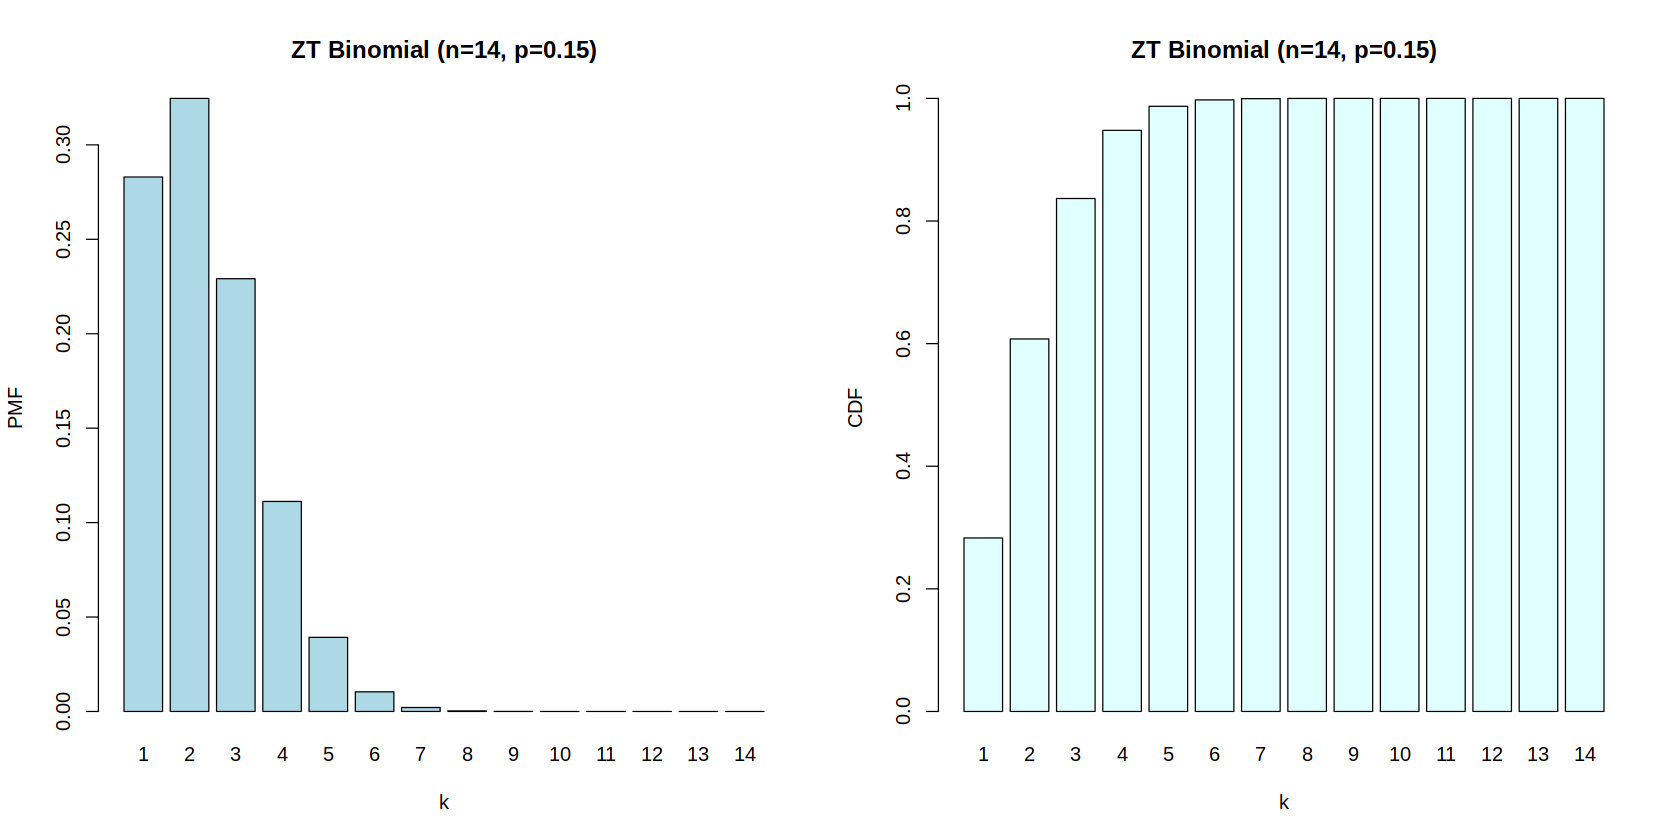

In [10]:
# VALUES:
n <- 14
p <- 0.15
k_values <- 1:n
pmf_val <- pmf_ztb(k_values, n, p)
cdf_val <- cdf_ztb(k_values, n, p)

# PLOT:
options(repr.plot.width = 14, repr.plot.height = 7)
par(mfrow = c(1, 2))  # 1 row and 2 columns
barplot( pmf_val, main='ZT Binomial (n=14, p=0.15)', ylab='PMF', xlab='k', col="lightblue", names.arg=k_values )
barplot( cdf_val, main='ZT Binomial (n=14, p=0.15)', ylab='CDF', xlab='k', col="lightcyan", names.arg=k_values )

#### 3. Compute the mean value and variance of the ZTB distribution using R. Compare the obtained values with the analytical statistical moments for the zero-truncated and the standard binomial distributions.

In [21]:
# NUMERICAL MEAN AND VARIANCE of ztb: (using definitions of mean and variance)
ztb_mean_num <- sum(k_values*pmf_val)
ztb_var_num  <- sum(k_values^2 * pmf_val) - ztb_mean_num^2
print( paste( 'NUMERICAL MEAN of ztb: ', format(ztb_mean_num, digits = 5) , ' VARIANCE: ' , format(ztb_var_num, digits = 5) ))

# ANALYTICAL MEAN AND VARIANCE of ztb:
ztb_mean_ana <- n*p / ( 1-(1-p)^n )
ztb_var_ana  <- (n*p*((1-p)-(1-p+n*p)*(1-p)^n))/(1-(1-p)^n)^2   # da fare un check
print( paste( 'ANALYTICAL MEAN of ztb:', format(ztb_mean_ana, digits = 5) , ' VARIANCE: ' , format(ztb_var_ana, digits = 5) ))

# ANALYTICAL MEAN AND VARIANCE of standard binomial:
bin_mean <- n*p
bin_var <- n*p*(1-p)
print( paste( 'ANALYTICAL MEAN of bin:', format(bin_mean, digits = 5) , ' VARIANCE: ' , format(bin_var, digits = 5) ))


[1] "NUMERICAL MEAN of ztb:  2.3405  VARIANCE:  1.4265"
[1] "ANALYTICAL MEAN of ztb: 2.3405  VARIANCE:  1.4265"
[1] "ANALYTICAL MEAN of bin: 2.1  VARIANCE:  1.785"


#### 4. Generate a sample of random numbers from this distribution, show them in an histogram, and evaluate the sample mean.

Mean value: 2.337962 


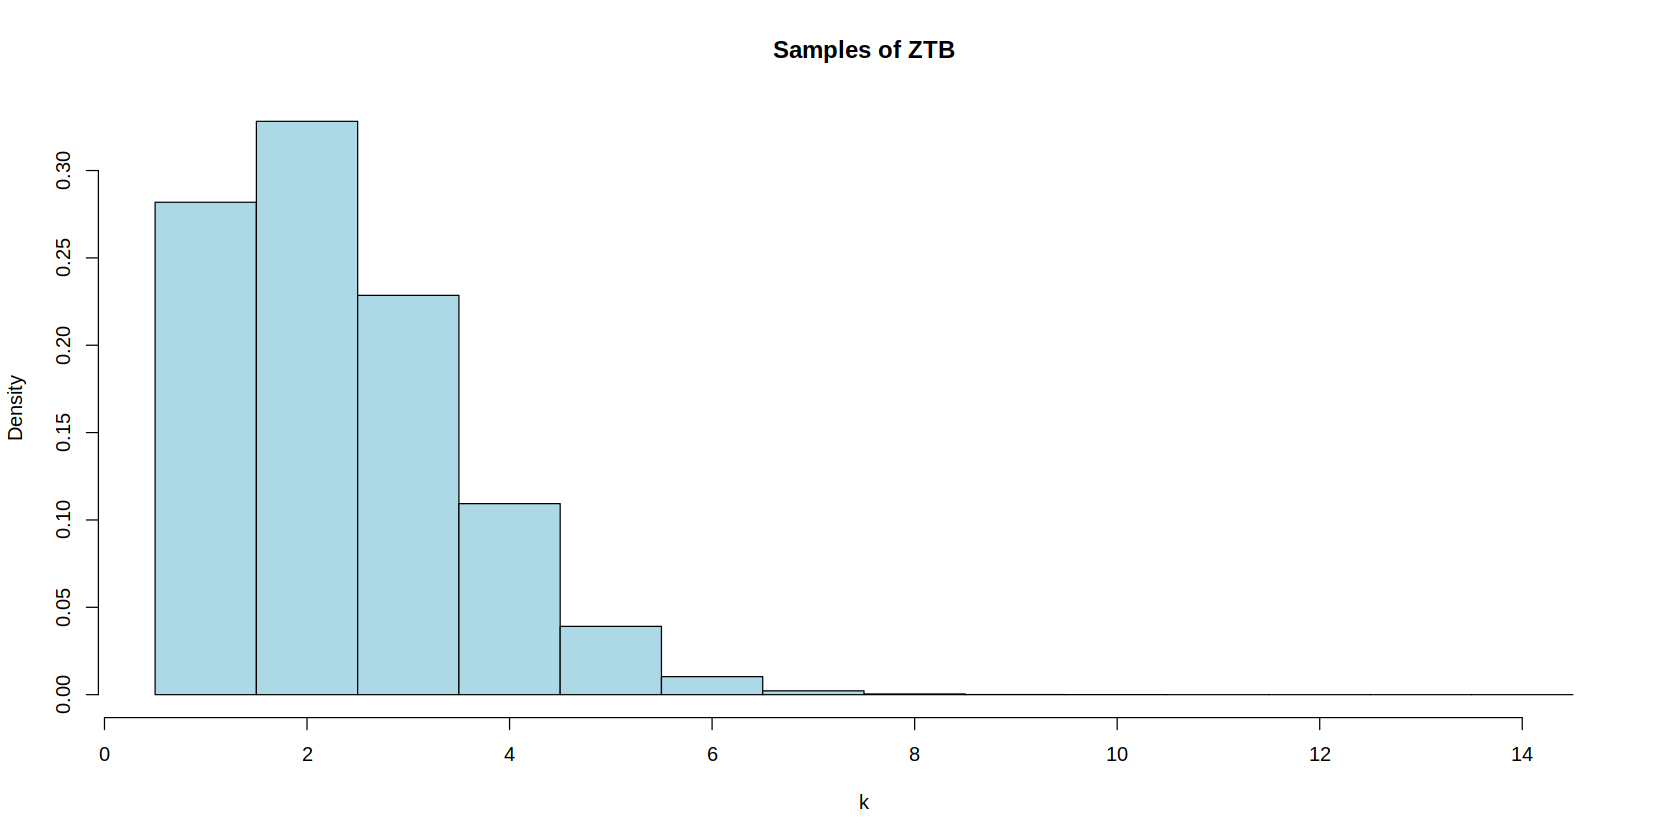

In [46]:
N <- 100000                        # number of samples
samples <- rbinom(N, n, p)
samples <- samples[samples != 0]   # removing zeros
mean_samples <- mean(samples)      # Compute sample mean

# PLOT:
hist(   samples,
        breaks = seq(1/2, 29/2,1), 
        xlab = "k", main = "Samples of ZTB", col = "lightblue",
        probability=TRUE
)

cat("Mean value:", mean_samples, "\n")

---

# Exercise 2 - Continuous random variable
The energy distribution of CR muons at sea level can be approximated as follows
$$
p(E) = N \begin{cases}
1 & \text{for } E < E_0 \\
(E - E_0 + 1)^{-\gamma} & \text{for } E \ge E_0
\end{cases}
$$
where $E_0 = 7.25$ GeV and $\gamma = 2.7$.

#### 1. Compute the normalisation factor N using R.

In [2]:
# PARAMETERS:
E0 <- 7.25     # GeV
gamma <- 2.7
N <- 1         # normalization initialized to 1

# PDF:
distrib <- function(E) {
    ifelse( E<E0, N, N*(E-E0+1)^(-gamma) )
}

# NORMALIZATION:
integration <- integrate(distrib, lower=0, upper=Inf)
N <- 1/integration$value
cat('Normalization factor: ', N)

Normalization factor:  0.1275797

#### 2. Plot the probability density function in R.

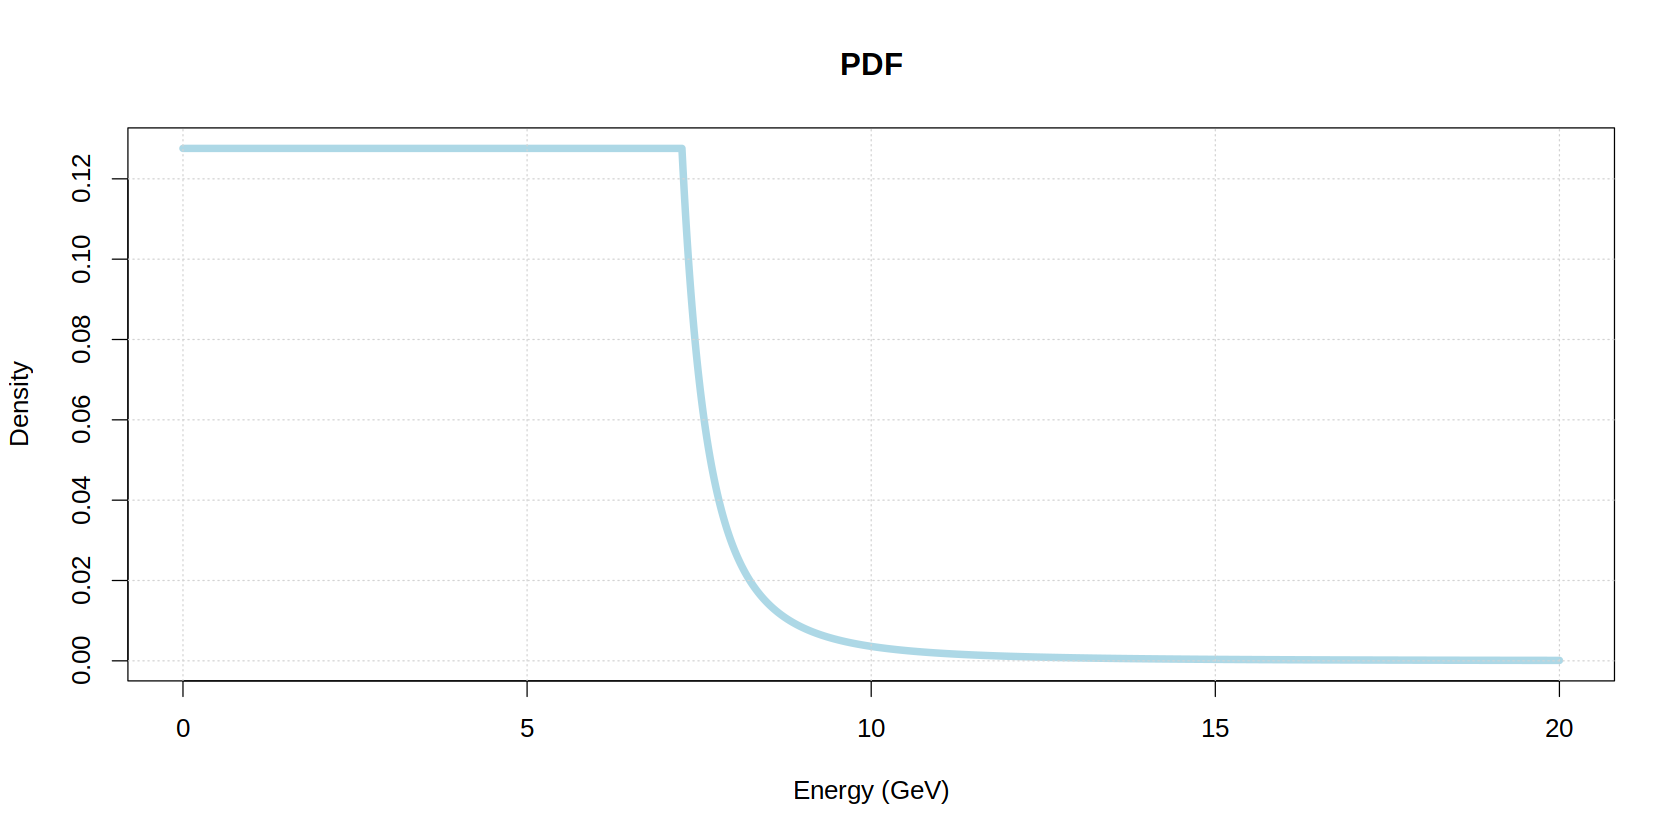

In [33]:
step <- 0.01
en_values <- seq(0,20, step)
y_values <- distrib(en_values)

# PLOT:
options(repr.plot.width = 14, repr.plot.height = 7)
par(cex=1.3) 
plot(en_values, y_values, 
     type='l', lwd=6, col = "lightblue", main='PDF', xlab='Energy (GeV)', ylab='Density')
grid()

#### 3. Plot the cumulative density function in R.

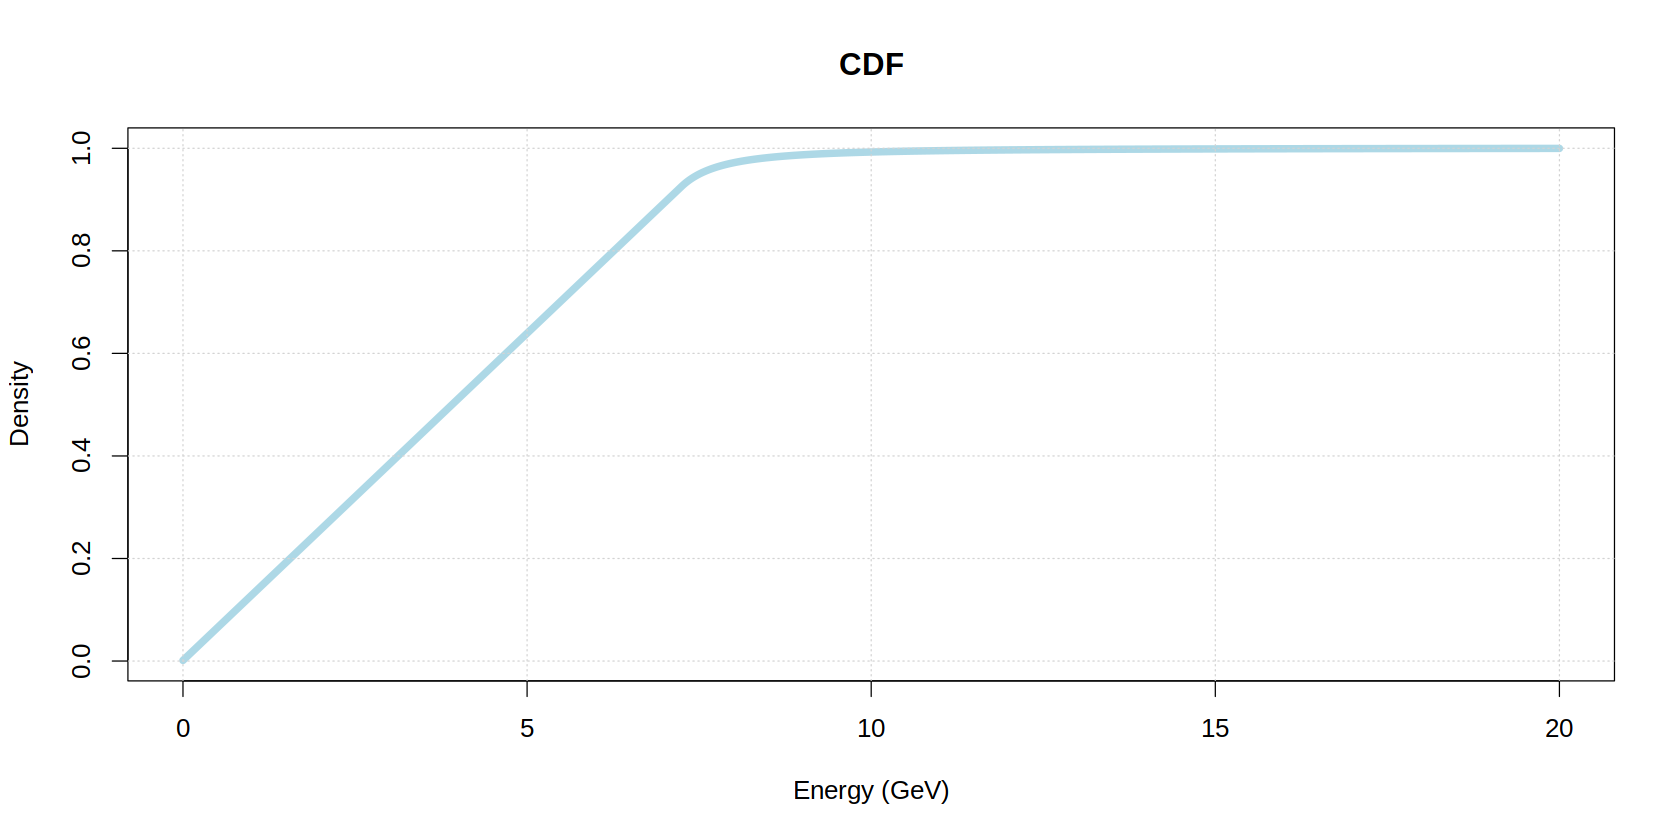

In [34]:
cdf_val <- cumsum(y_values*step)

# PLOT:
options(repr.plot.width = 14, repr.plot.height = 7)
par(cex=1.3) 
plot(en_values, cdf_val, 
     type='l', lwd=6, col = "lightblue", main='CDF', xlab='Energy (GeV)', ylab='Density')
grid()

#### 4. Compute the mean value using R.

In [41]:
# let's use the definition of mean for contiuous distributions:
f <- function(E) E * distrib(E)
mean_E <- integrate(f, lower=0, upper=Inf)$value
cat("Mean energy:", mean_E, " GeV")

Mean energy: 4.004251  GeV

#### 5. Generate 10^6 random numbers from this distribution, show them in an histogram and superimpose the pdf (with a line or with a sufficient number of points).

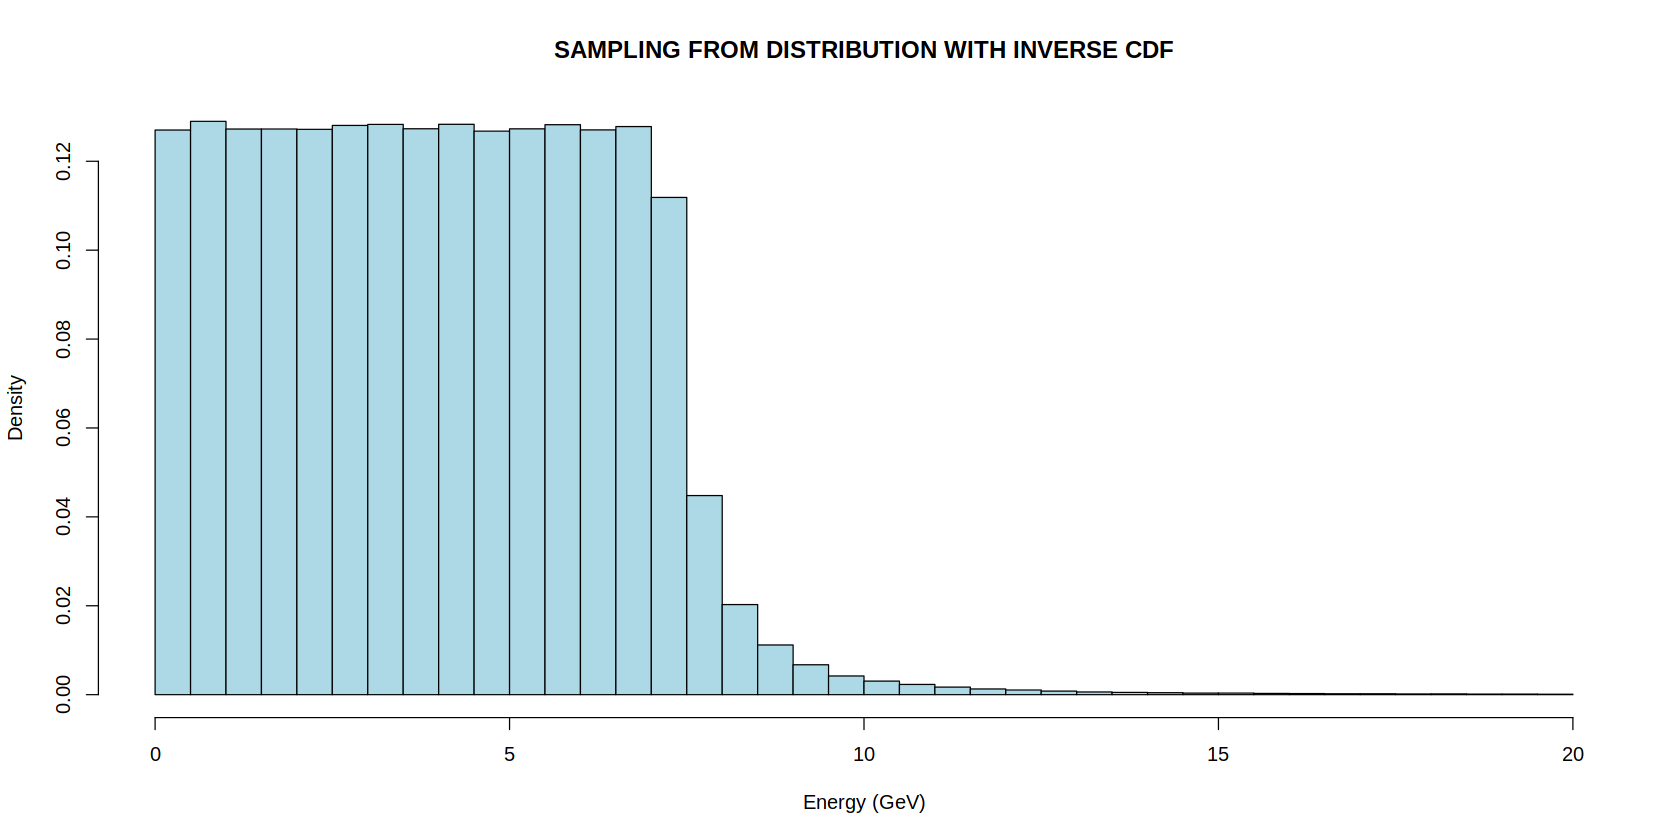

In [99]:
# let's use inverse cdf method (fromulae done by hand):
n <- 10^6
unif_samples <- runif(n, min = 0, max = 1)
# function that (given random numbers in [0,1]) returns values of E distributed like the above pdf:
inverse_cdf <- function(u) {
    ifelse ( u<N*E0, u/N, (1-(u-N*E0)*(gamma-1)/N )^( 1/(1-gamma) ) + (E0-1) )
}
samples <- inverse_cdf(unif_samples)
hist(samples[samples<20], breaks=50, probability=TRUE,
     col='lightblue', main='SAMPLING FROM DISTRIBUTION WITH INVERSE CDF', xlab='Energy (GeV)', ylab='Density')

---

# Exercise 3 - Web Server Requests
The average number of requests to a small web server is 7 per day.

In [101]:
avg <- 7

#### 1. Find a bound for the probability that at least 30 web server requests will occur tomorrow.

In [105]:
# using markov inequality: 
k <- 30
prob <- avg/k
cat("MARKOV INEQUALITY: Prob(req>30) <= ", format(prob, digits = 3))

MARKOV INEQUALITY: Prob(req>30) <=  0.233

#### 2. Under regular conditions, the number of web server requests can be modeled as Poisson process, calculate the probability that at least 30 requests will occur tomorrow. Compare this value with the bound obtained in the previous point 1.

In [109]:
prob_pois <- dpois(k, avg)
cat("POISSON PROB : ", format(prob_pois, digits = 3))

POISSON PROB :  7.75e-11

The obtained probability is  much smaller wrt the limit obtained by the markov inequality (but indeed smaller).

#### 3. Let the variance of the number of requests be 5 per day, find a bound on the probability that tomorrow at least 30 requests will occur.

In [113]:
# using chebyshev inequality:
variance <- 5
r <- (30-7)/sqrt(5)     # distance from mean expressed in standard deviations
prob_chebyshev <- 1/r^2
cat("CHEBYSHEV PROB: P(X ≥ 30) ≤", format(prob_chebyshev, digits = 3))

CHEBYSHEV PROB: P(X ≥ 30) ≤ 0.00945

---

# Exercise 4 - Photon Detector
A photon detector measures an average of 350 light particles per second with a standard deviation of 75 particles.\
How many minutes an experimentalist must run the detector to be 95% confident of collecting at least 1 million signals?

#### 1. How many minutes an experimentalist must run the detector to be 95% confident of collecting at least 1 million signals?

The sum of many independent random variables (each second) tends toward a normal distribution (by the Central Limit Theorem).   
So the number of particles over time follows a gaussian distribution.

In [7]:
# PARAMETERS:
num_sig <- 10^6      # total wanted number of signals
avg <- 350           # average number of signals per second
std <- 75            # standard deviation per second

sec_list <- 1:10000              # seconds to test
avg_tot <- avg*sec_list
std_tot <- std*sqrt(sec_list)
# let's compute the confidence level (= cumulative prob) for each value of time passed:
conf_level <- pnorm(num_sig, avg_tot, std_tot, lower.tail=FALSE)
# let's find the first time when we have 95 confidence:
minimum_seconds <- which.max(conf_level >= 0.95)
print( paste( 'Minimum time:', minimum_seconds%/%60 , 'minutes and ' , minimum_seconds%%60 , 'seconds') )

[1] "Minimum time: 47 minutes and  57 seconds"


---

# Exercise 5 - Rumor Spreading Process
Let a small community be composed of 1000 persons.\
Initially, 5 people know a rumor, and 995 people don’t.\
Every person who knows the rumor spreads it to one randomly chosen person, including those who already know it.

#### 1. Simulate how the rumor spreads over 15 interactions using R.

---

# Exercise 6 - Passenger Arrivals
In a stationary bus at the departure station, a passenger gets on the bus, on average every 30 seconds.